# EgoDyn-Bench — Dataset & Benchmark Statistics

A tutorial walkthrough of the curated EgoDyn-Bench dataset. We load the
public benchmark file and the per-clip arrays, then show how to compute
the statistics reported in the paper:

- Source composition (nuScenes vs. CARLA)
- Per-question answer-class distributions
- Answer-balance scores (normalised entropy)
- Per-source dynamics-feature distributions
- Behavior co-occurrence patterns
- A peek at threshold-sensitivity data

You can launch this notebook from anywhere in the repo — the next cell
climbs the directory tree until it finds the project root.

> **Note:** the "dynamics features" cell loads `.npz` arrays from
> `output/{nuscenes,carla}_clips/arrays/`. These are gitignored. If the
> directory is empty, regenerate them first with
> `dataset/scripts/extract_nuscenes_clips.py` and
> `dataset/scripts/extract_carla_clips.py` — see `docs/DATASET_GENERATION.md`.

In [1]:
"""Bootstrap: imports, project-root resolution, and plotting defaults."""
%matplotlib inline

import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Walk up until we find the project root (sentinel: selected_clips.json).
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "selected_clips.json").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError(f"Project root not found from {Path.cwd()}")
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Reuse the website figure helpers for colours and labels.
# The scripts call matplotlib.use("Agg") on import — restore inline after.
from scripts.visualize_distributions import SOURCE_COLORS, FEATURE_LABELS
from scripts.visualize_website import QUESTION_LABELS
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 10,
})

print(f"Project root: {PROJECT_ROOT}")


Project root: /home/finn-avs1/Documents/coding/dynamic-trajectory-understanding


## 1. Load the curated benchmark

The released benchmark spec lives in `selected_clips.json` at the repo
root. Each entry has four fields:

| field | content |
|---|---|
| `id` | clip identifier — matches an `.npz` filename in `output/.../arrays/` |
| `source` | `"nuscenes"` or `"carla"` |
| `features` | per-clip summary statistics (mean speed, peak accel, …) |
| `answers` | oracle label per question, one of the question's discrete choices |


In [2]:
with open(PROJECT_ROOT / "selected_clips.json") as f:
    clips = json.load(f)

print(f"Total clips: {len(clips)}")
print(f"Sources:     {dict(Counter(c['source'] for c in clips))}")
print(f"Questions:   {len(clips[0]['answers'])}")
print()
print("Example clip (truncated):")
ex = clips[0]
print(f"  id:       {ex['id']}")
print(f"  source:   {ex['source']}")
print(f"  features: {list(ex['features'])[:5]} ...")
print(f"  answers:  {dict(list(ex['answers'].items())[:3])} ...")


Total clips: 1000
Sources:     {'nuscenes': 500, 'carla': 500}
Questions:   14

Example clip (truncated):
  id:       clip_19765
  source:   nuscenes
  features: ['max_abs_yaw_rate', 'min_accel', 'mean_abs_jerk', 'mean_speed', 'total_heading_change'] ...
  answers:  {'yaw_rate_turn_direction': 'right', 'braking_intensity': 'moderate', 'speed_regime': 'slow'} ...


## 2. Source composition

EgoDyn-Bench draws clips from real-world nuScenes (CC BY-NC-SA) and
CARLA scenarios augmented with Cosmos Transfer. The 50/50 split is
enforced by `scripts/select_balanced_clips.py` during curation.

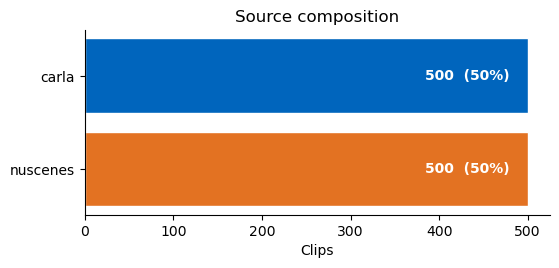

In [3]:
source_counts = Counter(c["source"] for c in clips)
sources = ["nuscenes", "carla"]
counts  = [source_counts[s] for s in sources]

fig, ax = plt.subplots(figsize=(6, 2.4))
bars = ax.barh(sources, counts,
               color=[SOURCE_COLORS[s] for s in sources], edgecolor="white")
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() - 20, bar.get_y() + bar.get_height() / 2,
            f"{c}  ({c / sum(counts):.0%})",
            va="center", ha="right", color="white", fontweight="bold")
ax.set_xlabel("Clips")
ax.set_title("Source composition")
plt.show()


## 3. Per-question answer distribution

Each clip carries a discrete oracle label for all 14 questions. Because
Balanced Accuracy and Macro-F1 are sensitive to class skew, it's worth
seeing how often each answer class appears for each question.

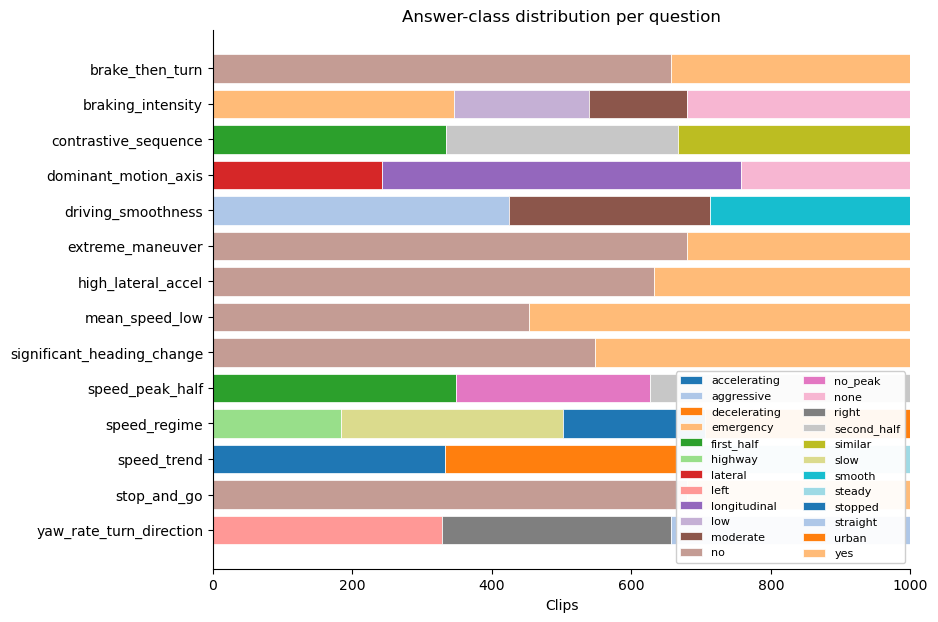

In [4]:
all_questions = sorted(clips[0]["answers"].keys())
per_q_counts = {q: Counter(c["answers"][q] for c in clips)
                for q in all_questions}

classes_seen = sorted({cls for q in all_questions for cls in per_q_counts[q]})
palette = sns.color_palette("tab20", len(classes_seen))
class_color = dict(zip(classes_seen, palette))

fig, ax = plt.subplots(figsize=(9, 7))
bottom = np.zeros(len(all_questions))
for cls in classes_seen:
    vals = np.array([per_q_counts[q].get(cls, 0) for q in all_questions])
    if vals.sum() == 0:
        continue
    ax.barh(all_questions, vals, left=bottom, label=cls,
            color=class_color[cls], edgecolor="white", linewidth=0.5)
    bottom += vals

ax.invert_yaxis()
ax.set_xlabel("Clips")
ax.set_title("Answer-class distribution per question")
ax.legend(loc="lower right", fontsize=8, ncol=2, framealpha=0.95)
plt.show()


## 4. Balance score (normalised entropy)

A compact summary of per-question class balance is **normalised entropy**:
$\;H(p) / \log(K)$, where $K$ is the number of answer classes for that
question. A score of **1.0** is perfectly uniform; **0.0** is degenerate
(a single class).

This is exactly the metric reported in the "Answer Balance" figure of the
paper, and we compute it inline here so the math is visible (the same
helper is wrapped in `scripts.visualize_distributions._balance_score`).

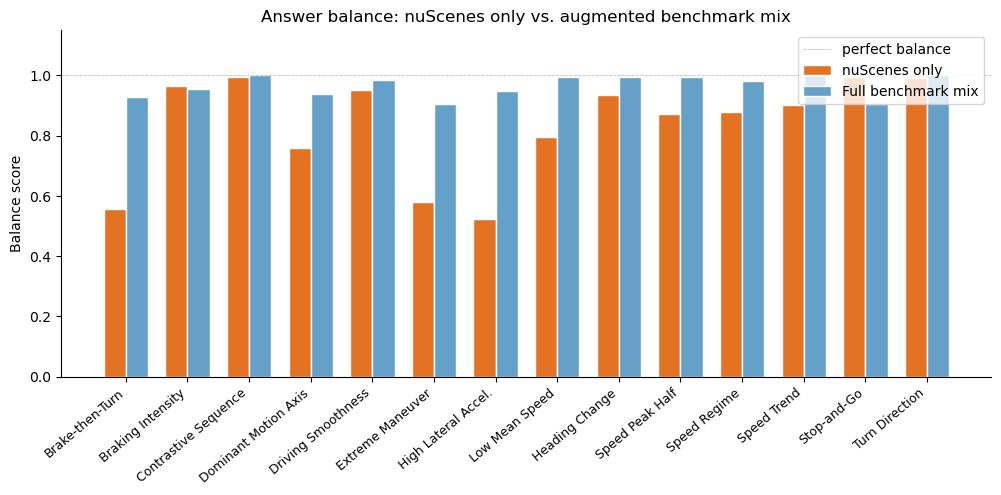

In [5]:
def balance_score(label_dicts, question):
    """Normalised entropy of a question's answer distribution.

    Returns a value in [0, 1]: 1.0 = perfectly uniform, 0.0 = single class.
    """
    answers = [d[question] for d in label_dicts if question in d]
    if not answers:
        return 0.0
    counts = Counter(answers)
    if len(counts) <= 1:
        return 0.0
    total = sum(counts.values())
    entropy = -sum((c / total) * np.log(c / total) for c in counts.values())
    return float(entropy / np.log(len(counts)))


ns_labels  = [c["answers"] for c in clips if c["source"] == "nuscenes"]
all_labels = [c["answers"] for c in clips]

ns_scores  = [balance_score(ns_labels,  q) for q in all_questions]
all_scores = [balance_score(all_labels, q) for q in all_questions]

x = np.arange(len(all_questions))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - 0.18, ns_scores,  width=0.36, color=SOURCE_COLORS["nuscenes"],
       label="nuScenes only", edgecolor="white")
ax.bar(x + 0.18, all_scores, width=0.36, color=SOURCE_COLORS["combined"],
       label="Full benchmark mix", edgecolor="white")
ax.axhline(1.0, color="grey", ls="--", lw=0.6, alpha=0.5,
           label="perfect balance")
ax.set_xticks(x)
ax.set_xticklabels([QUESTION_LABELS.get(q, q) for q in all_questions],
                   rotation=40, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Balance score")
ax.set_title("Answer balance: nuScenes only vs. augmented benchmark mix")
ax.legend()
plt.show()


## 5. Dynamics-feature distributions per source

Each clip carries seven scalar dynamics summaries in its `features` field
— peak speed, peak deceleration, mean jerk, peak lateral acceleration,
peak yaw rate, total heading change. These are the same features used by
the paper's "Feature Distributions" figure.

We compare nuScenes and CARLA side by side as KDEs, clipped to the 1st–99th
percentile of the combined distribution so outliers don't dominate the axis.

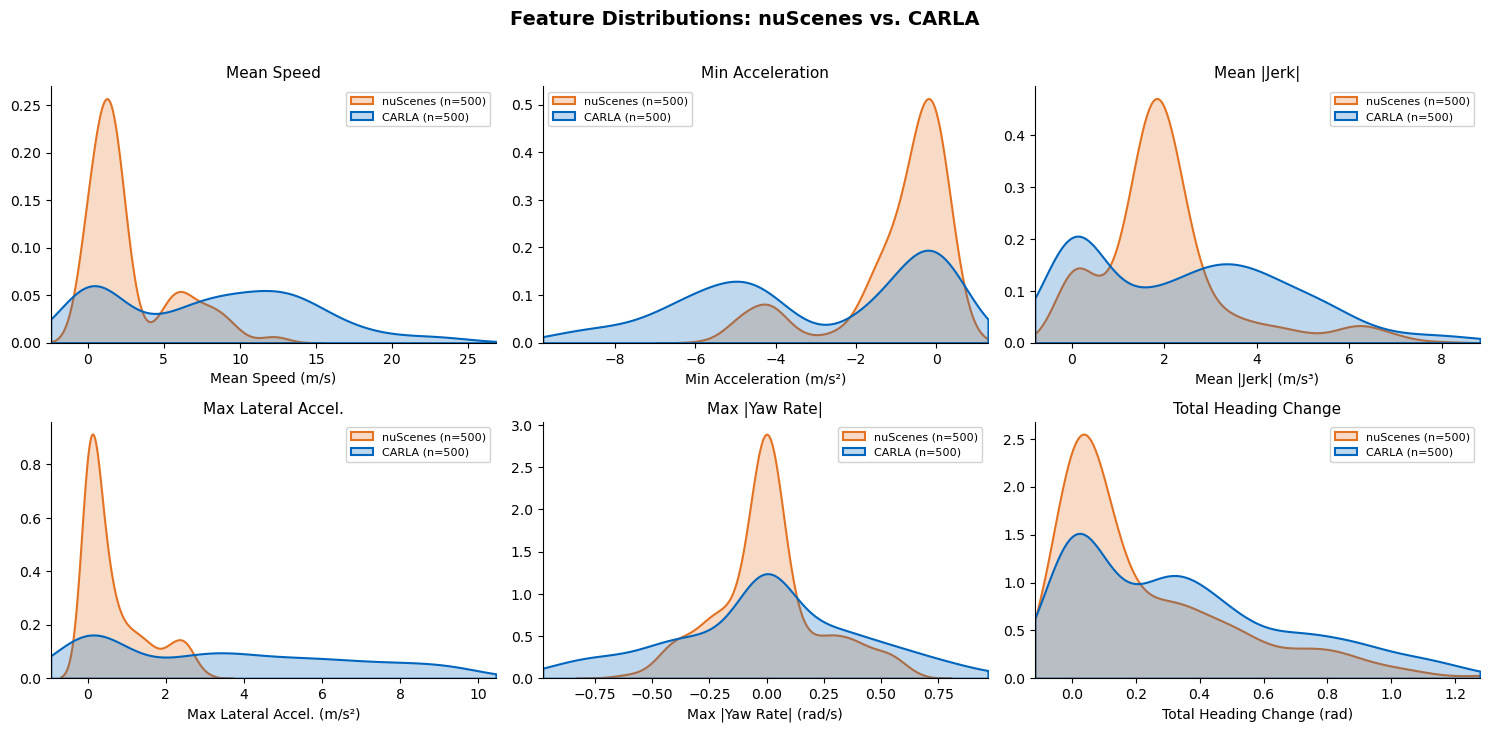

In [6]:
# Same set the website figure uses (filtered to what actually exists).
from scripts.visualize_distributions import FEATURE_LABELS
features = [f for f in FEATURE_LABELS if any(f in c["features"] for c in clips)]

ns_clips = [c for c in clips if c["source"] == "nuscenes"]
ca_clips = [c for c in clips if c["source"] == "carla"]

ncols = 3
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    label, unit = FEATURE_LABELS[feat]
    ns_vals = [c["features"][feat] for c in ns_clips if feat in c["features"]]
    ca_vals = [c["features"][feat] for c in ca_clips if feat in c["features"]]

    # Clip x-range to the central 98% so outliers don't flatten the curve.
    p1, p99 = np.percentile(ns_vals + ca_vals, [1, 99])
    margin = 0.1 * max(abs(p1), abs(p99), 0.01)
    xlim = (p1 - margin, p99 + margin)

    sns.kdeplot(ns_vals, ax=ax, color=SOURCE_COLORS["nuscenes"],
                fill=True, alpha=0.25, linewidth=1.5, clip=xlim,
                label=f"nuScenes (n={len(ns_vals)})")
    sns.kdeplot(ca_vals, ax=ax, color=SOURCE_COLORS["carla"],
                fill=True, alpha=0.25, linewidth=1.5, clip=xlim,
                label=f"CARLA (n={len(ca_vals)})")

    ax.set_xlabel(f"{label} ({unit})")
    ax.set_ylabel("")
    ax.set_title(label, fontsize=11)
    ax.set_xlim(xlim)
    ax.legend(fontsize=8, framealpha=0.9)

# Hide leftover subplots.
for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Feature Distributions: nuScenes vs. CARLA",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 6. Behavior co-occurrence

Several question pairs are correlated by physics — a clip that turns is
likely to also have high lateral acceleration. The co-occurrence matrix
makes these correlations explicit.

For questions with a natural binary collapse (yes/no, or "interesting"
vs neutral category), we mark each clip as positive/negative and compute
the pairwise Jaccard coefficient $|A \cap B| / |A \cup B|$. The four
multi-class questions without an obvious binary form (`speed_regime`,
`speed_trend`, `speed_peak_half`, `contrastive_sequence`) are omitted.

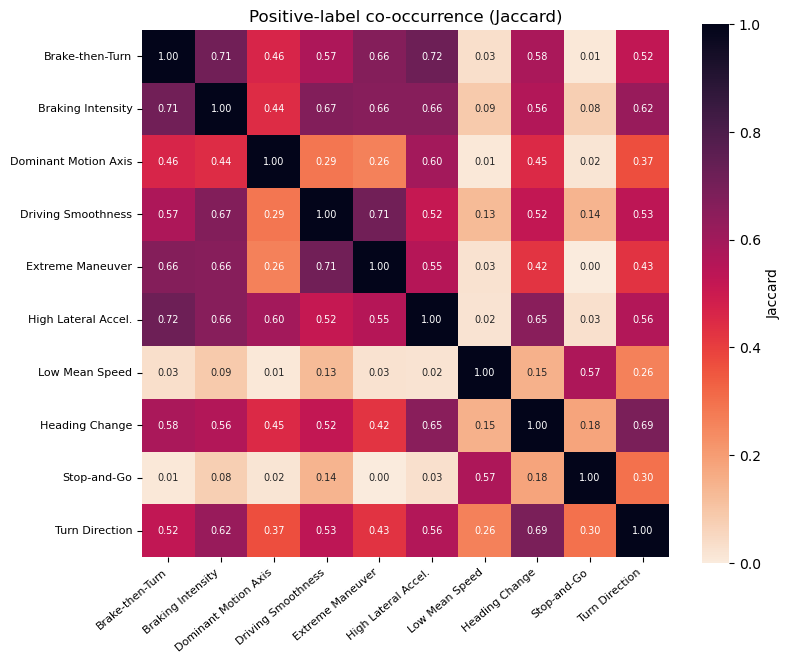

In [7]:
# Explicit per-question rule for what counts as a "positive" label.
POSITIVE = {
    "brake_then_turn":            lambda a: a == "yes",
    "braking_intensity":          lambda a: a in {"moderate", "emergency"},
    "driving_smoothness":         lambda a: a == "aggressive",
    "dominant_motion_axis":       lambda a: a == "lateral",
    "extreme_maneuver":           lambda a: a == "yes",
    "high_lateral_accel":         lambda a: a == "yes",
    "mean_speed_low":             lambda a: a == "yes",
    "significant_heading_change": lambda a: a == "yes",
    "stop_and_go":                lambda a: a == "yes",
    "yaw_rate_turn_direction":    lambda a: a in {"left", "right"},
}

qs = sorted(POSITIVE.keys())
mat = np.array([[POSITIVE[q](c["answers"].get(q)) for q in qs] for c in clips])

n = len(qs)
jac = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a, b = mat[:, i], mat[:, j]
        union = (a | b).sum()
        jac[i, j] = (a & b).sum() / union if union > 0 else 0.0

labels = [QUESTION_LABELS.get(q, q).replace("\n", " ") for q in qs]
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(jac, ax=ax, cmap="rocket_r", vmin=0, vmax=1, square=True,
            xticklabels=labels, yticklabels=labels, annot=True, fmt=".2f",
            annot_kws={"fontsize": 7}, cbar_kws={"label": "Jaccard"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8, rotation=0)
ax.set_title("Positive-label co-occurrence (Jaccard)")
plt.show()


## 7. Threshold-sensitivity peek

The paper's appendix studies how stable each question's oracle labels
are when the labelling threshold is perturbed by $\alpha \in [0.5, 1.5]$.
Raw data lives in `assets/figures/sensitivity/per_threshold_sensitivity.json`.

Below we plot the label flip rate for four questions across α — the
full version (all 14) is produced by
`python scripts/per_threshold_sensitivity.py`.

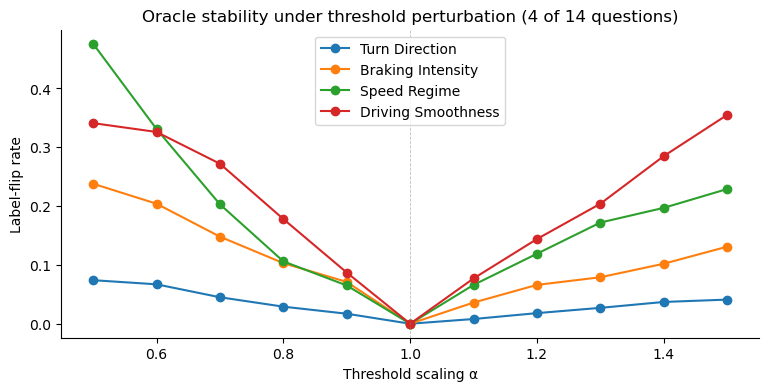

In [8]:
sens_path = (PROJECT_ROOT / "assets" / "figures" / "sensitivity"
             / "per_threshold_sensitivity.json")
with open(sens_path) as f:
    sens = json.load(f)

alphas = sens["factors"]
fig, ax = plt.subplots(figsize=(9, 4))
for qid in ["yaw_rate_turn_direction", "braking_intensity", "speed_regime",
            "driving_smoothness"]:
    rates = [sens["per_question"][qid]["label_flip_rates"][str(a)]
             for a in alphas]
    ax.plot(alphas, rates, "o-",
            label=QUESTION_LABELS.get(qid, qid).replace("\n", " "))
ax.axvline(1.0, color="grey", ls="--", lw=0.6, alpha=0.5)
ax.set_xlabel("Threshold scaling α")
ax.set_ylabel("Label-flip rate")
ax.set_title("Oracle stability under threshold perturbation (4 of 14 questions)")
ax.legend()
plt.show()


## Next steps

- **`failure_analysis.ipynb`** — load model results, build confusion matrices,
  pull raw failure cases from `generated/`.
- **`docs/EVALUATION.md`** — how to run a new model through the eval harness.
- **`dataset/scripts/extract_*.py`** — regenerate per-clip arrays from raw data.
- **`scripts/clip_viewer.py`** — interactive browser for individual clips.